In [2]:
!pip install -q requests

In [13]:
import requests
from google.colab import userdata

api_key = userdata.get('OPENROUTER_API_KEY')

response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/text-embedding-3-small",
        "input": "The quick brown fox jumps over the lazy dog"
    }
)

response.raise_for_status()

data = response.json()
embedding = data["data"][0]["embedding"]
print(f"Embedding dimension: {len(embedding)}")

Embedding dimension: 1536


In [14]:
import requests
import numpy as np
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

documents = [
    "The cat sat on the mat",
    "Dogs are loyal companions",
    "Python is a programming language",
    "Machine learning models require training data",
    "The weather is sunny today"
]

def cosine_similarity(a, b):
    """Calculate cosine similarity between two vectors"""
    dot_product = np.dot(a, b)
    magnitude_a = np.linalg.norm(a)
    magnitude_b = np.linalg.norm(b)
    return dot_product / (magnitude_a * magnitude_b)

def semantic_search(query, documents):
    """Perform semantic search using embeddings"""
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": "openai/text-embedding-3-small",
            "input": [query] + documents
        }
    )

    response.raise_for_status()

    data = response.json()
    query_embedding = np.array(data["data"][0]["embedding"])
    doc_embeddings = [np.array(item["embedding"]) for item in data["data"][1:]]

    results = []
    for i, doc in enumerate(documents):
        similarity = cosine_similarity(query_embedding, doc_embeddings[i])
        results.append({"document": doc, "similarity": float(similarity)})

    results.sort(key=lambda x: x["similarity"], reverse=True)

    return results

results = semantic_search("pets and animals", documents)
print("Search results:")
for i, result in enumerate(results):
    print(f"{i + 1}. {result['document']} (similarity: {result['similarity']:.4f})")

Search results:
1. Dogs are loyal companions (similarity: 0.4183)
2. The cat sat on the mat (similarity: 0.3531)
3. Python is a programming language (similarity: 0.1502)
4. Machine learning models require training data (similarity: 0.1329)
5. The weather is sunny today (similarity: 0.1197)


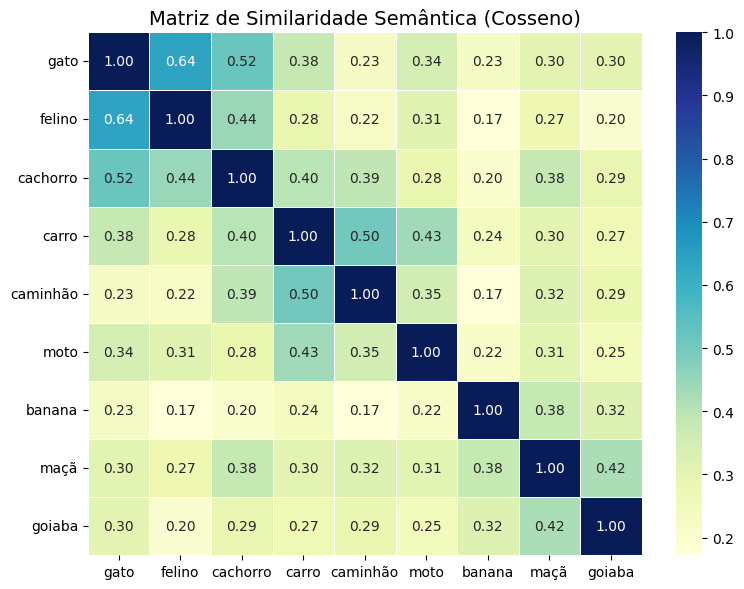

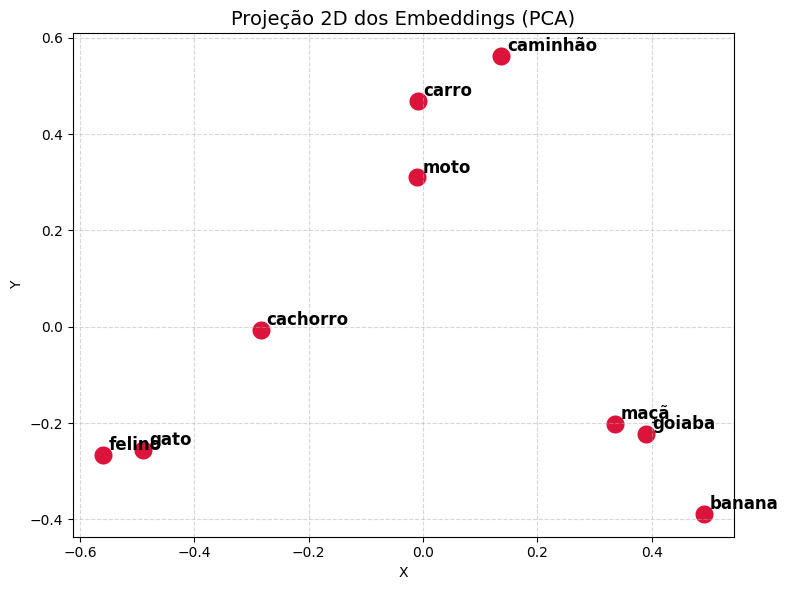

In [18]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

palavras = [
    "gato", "felino", "cachorro",
    "carro", "caminhão", "moto",
    "banana", "maçã", "goiaba"
]

def gerar_dicionario_embeddings(lista_palavras):
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": "openai/text-embedding-3-small",
            "input": lista_palavras
        }
    )

    response.raise_for_status()
    data = response.json()

    embeddings_dict = {}
    for item, palavra in zip(data["data"], lista_palavras):
        embeddings_dict[palavra] = np.array(item["embedding"])

    return embeddings_dict

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 1. Gerar embeddings e Matriz de Similaridade
embeddings_db = gerar_dicionario_embeddings(palavras)

matriz_similaridade = {}
for p1 in palavras:
    matriz_similaridade[p1] = {}
    for p2 in palavras:
        sim = cosine_similarity(embeddings_db[p1], embeddings_db[p2])
        matriz_similaridade[p1][p2] = round(float(sim), 3)

df_similaridade = pd.DataFrame(matriz_similaridade)

# ==========================================
# VISUALIZAÇÃO 1: HEATMAP 2D DA MATRIZ
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(df_similaridade, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Similaridade Semântica (Cosseno)", fontsize=14)
plt.tight_layout()
plt.show()

# Extração da matriz de vetores para redução de dimensionalidade
X = np.array([embeddings_db[p] for p in palavras])

# ==========================================
# VISUALIZAÇÃO 2: GRÁFICO 2D (PCA)
# ==========================================
pca_2d = PCA(n_components=2)
coords_2d = pca_2d.fit_transform(X)

df_2d = pd.DataFrame({
    'Palavra': palavras,
    'X': coords_2d[:, 0],
    'Y': coords_2d[:, 1]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_2d, x='X', y='Y', s=200, color='crimson')

for i in range(len(df_2d)):
    plt.text(
        df_2d['X'][i] + 0.01,
        df_2d['Y'][i] + 0.01,
        df_2d['Palavra'][i],
        fontsize=12,
        weight='bold'
    )

plt.title("Projeção 2D dos Embeddings (PCA)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZAÇÃO 3: GRÁFICO 3D INTERATIVO (Plotly)
# ==========================================
pca_3d = PCA(n_components=3)
coords_3d = pca_3d.fit_transform(X)

df_3d = pd.DataFrame({
    'Palavra': palavras,
    'Dim1': coords_3d[:, 0],
    'Dim2': coords_3d[:, 1],
    'Dim3': coords_3d[:, 2]
})

fig = px.scatter_3d(
    df_3d,
    x='Dim1',
    y='Dim2',
    z='Dim3',
    text='Palavra',
    title="Espaço Semântico 3D dos Embeddings (Interativo)",
    color='Palavra'
)
fig.update_traces(marker=dict(size=8), textposition="top center")
fig.show()